In [37]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter
plt.style.use("paper.mplstyle")

In [16]:
Original = "../Files/L1H1-PHASE_TIME_AMP_O4b.hdf"
Modified = "../Files/LH_Samples_Mod.hdf"

In [17]:
with h5py.File(Original, "r") as f:
    pwidth = f.attrs['pwidth']
    twidth = f.attrs["twidth"]
    swidth = f.attrs["swidth"]
    param_bin = np.array(f['L1']['param_bin'])

    weights = np.array(f['L1']['weights'])

with h5py.File(Modified, "r") as f:
    pwidth2 = f.attrs['pwidth']
    twidth2 = f.attrs["twidth"]
    swidth2 = f.attrs["swidth"]
    param_bin2 = np.array(f['L1']['param_bin'])
    weights2 = np.array(f['L1']['weights'])
bin_volume = (twidth * pwidth * swidth) ** (2 - 1)
bin_volume2 = (twidth2 * pwidth2 * swidth2) ** (2 - 1)

param_bin_ORIGINAL = param_bin
weights_ORIGINAL = (weights / (np.sum(weights)* bin_volume ))

param_bin_NEW = param_bin2
weights_NEW = (weights2 / (np.sum(weights2)* bin_volume2 ))

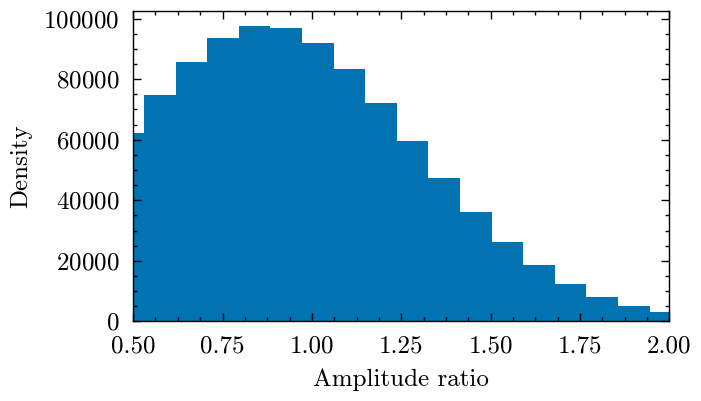

In [58]:

ratio_2 = 2/swidth
ratio_05 = 0.5/swidth


bins_ORIGINAL = np.max(param_bin_ORIGINAL["c2"])-np.min(param_bin_ORIGINAL["c2"])
plt.hist(param_bin_ORIGINAL["c2"], weights=weights_ORIGINAL, bins=bins_ORIGINAL)

plt.xlim(ratio_05,ratio_2)

physical_ticks = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0])
bin_ticks = physical_ticks / swidth

plt.gca().set_xticks(bin_ticks)

# Formatter stays exactly the same
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: f"{val * swidth:.2f}")
)
plt.ylabel("Density")
plt.xlabel("Amplitude ratio")
plt.savefig("../Plots/linear_sr.png")
plt.show()

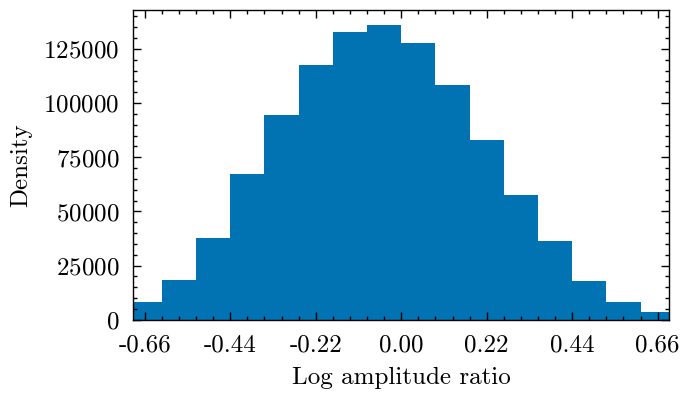

In [59]:
ratio_2 = np.log(2)/swidth2
ratio_05 = np.log(0.5)/swidth2
bins_NEW = np.max(param_bin_NEW["c2"])-np.min(param_bin_NEW["c2"])
plt.hist(param_bin_NEW["c2"], weights=weights_NEW, bins=bins_NEW)

plt.xlim(ratio_05,ratio_2)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: f"{val * swidth2:.2f}")
)
plt.ylabel("Density")
plt.xlabel("Log amplitude ratio")
plt.savefig("../Plots/log_sr.png")
plt.show()